# Decision Tree Visualization Using dtreeviz library

In [ ]:
# !pip install dtreeviz

In [ ]:
import graphviz.backend as be
from sklearn.datasets import load_iris
from IPython.display import Image, display_svg, SVG
from sklearn.tree import DecisionTreeClassifier

In [ ]:
iris = load_iris()
X_train = iris.data
y_train = iris.target

In [ ]:
# clas = DecisionTreeClassifier(max_depth=2)
clas = DecisionTreeClassifier()
clas.fit(X_train, y_train)

DecisionTreeClassifier()

[Text(0.5, 0.9166666666666666, 'x[3] <= 0.8\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.4230769230769231, 0.75, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.46153846153846156, 0.8333333333333333, 'True  '),
 Text(0.5769230769230769, 0.75, 'x[3] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5384615384615384, 0.8333333333333333, '  False'),
 Text(0.3076923076923077, 0.5833333333333334, 'x[2] <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.15384615384615385, 0.4166666666666667, 'x[3] <= 1.65\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.07692307692307693, 0.25, 'gini = 0.0\nsamples = 47\nvalue = [0, 47, 0]'),
 Text(0.23076923076923078, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.46153846153846156, 0.4166666666666667, 'x[3] <= 1.55\ngini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.38461538461538464, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.5384615384615384, 0.25, '

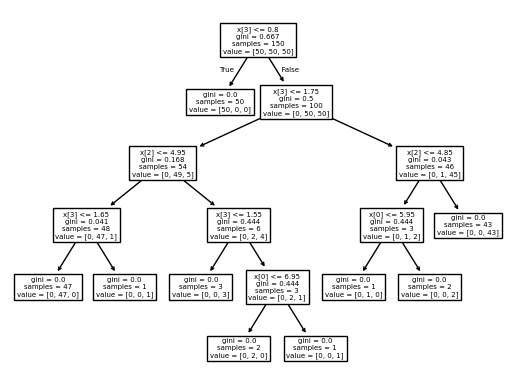

In [ ]:
from sklearn.tree import plot_tree
plot_tree(clas)

In [ ]:
# !pip install graphviz

# 1. Classification

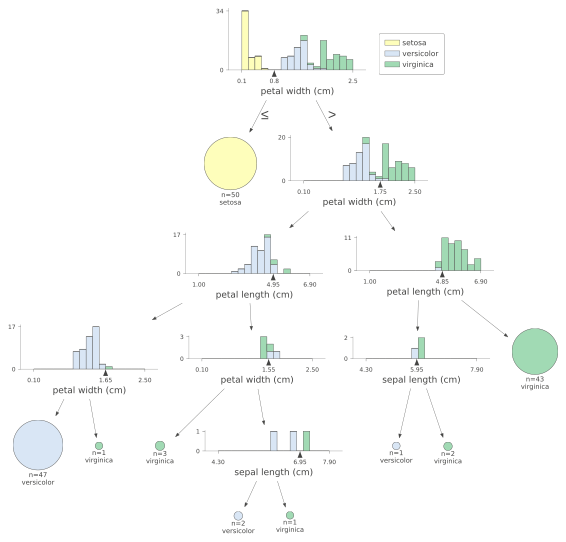

In [ ]:
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

from dtreeviz import model
m = model(
    clas,
    X_train=X_train,
    y_train=y_train,
    feature_names=iris.feature_names,
    class_names=['setosa', 'versicolor', 'virginica']
)

# m.view(scale=1.5) # zoom
m.view()

# 2. Regression

In [ ]:
import pandas as pd
from sklearn.datasets import load_diabetes

In [ ]:
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [ ]:
X_train = df.drop('target', axis=1)
y_train = df['target']

In [ ]:
from sklearn.tree import DecisionTreeRegressor
reg_model = DecisionTreeRegressor(max_depth=2)
reg_model.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=2)

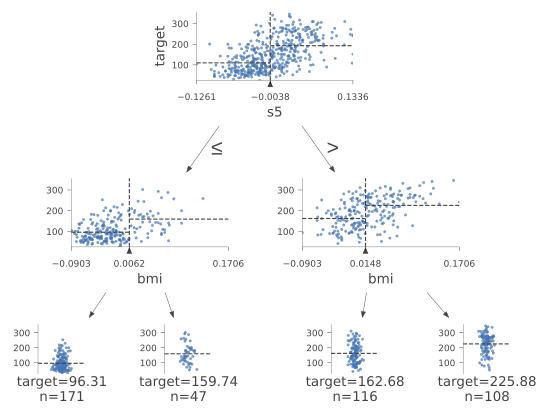

In [ ]:
viz = model(
    reg_model,
    X_train=X_train,
    y_train=y_train,
    target_name='target',
    feature_names=df.columns
)
viz.view(scale=1.5)

# 3. Horizontal Decision Tree

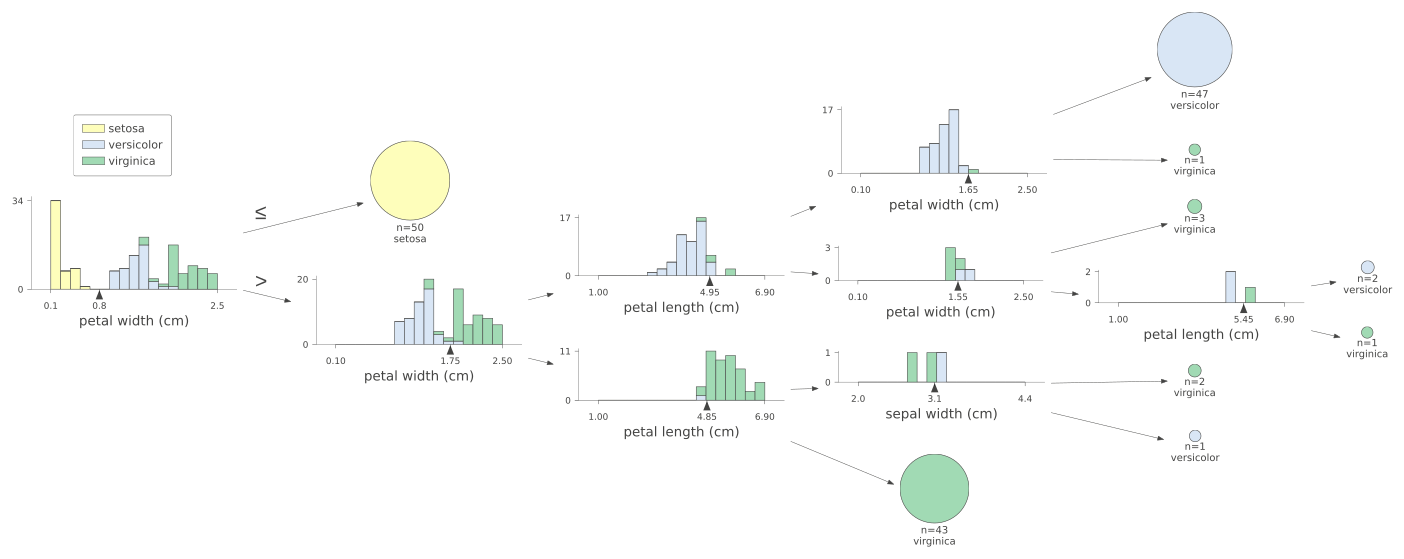

In [ ]:
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
clas = DecisionTreeClassifier()
clas.fit(X_iris, y_iris)

m = model(
    clas,
    X_train=X_iris,
    y_train=y_iris,
    feature_names=iris.feature_names,
    class_names=['setosa', 'versicolor', 'virginica']
)

m.view(orientation='LR',scale=1.5)

# 4. Show Prediction Path

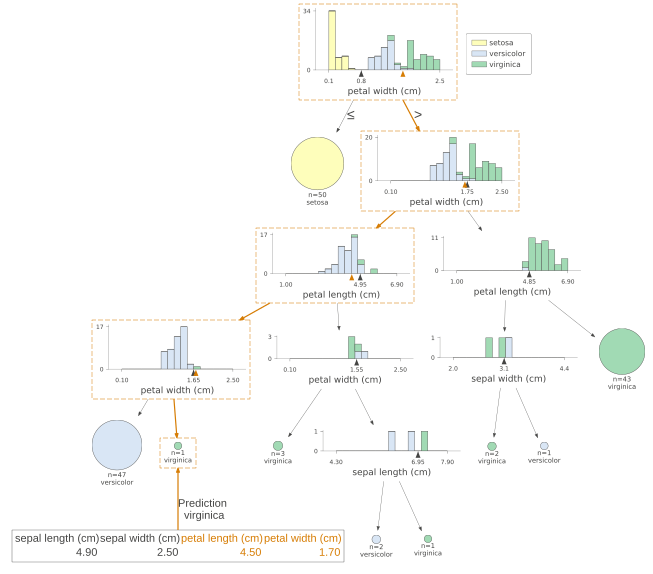

In [ ]:
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

import numpy as np
from dtreeviz import model
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

clas = DecisionTreeClassifier()
clas.fit(X_iris, y_iris)

X = iris.data[np.random.randint(0, len(iris.data)),:]


m = model(
    clas,
    X_train=X_iris,
    y_train=y_iris,
    feature_names=iris.feature_names,
    class_names=['setosa', 'versicolor', 'virginica']
)

m.view(x=X)

# 5. Show Node Number

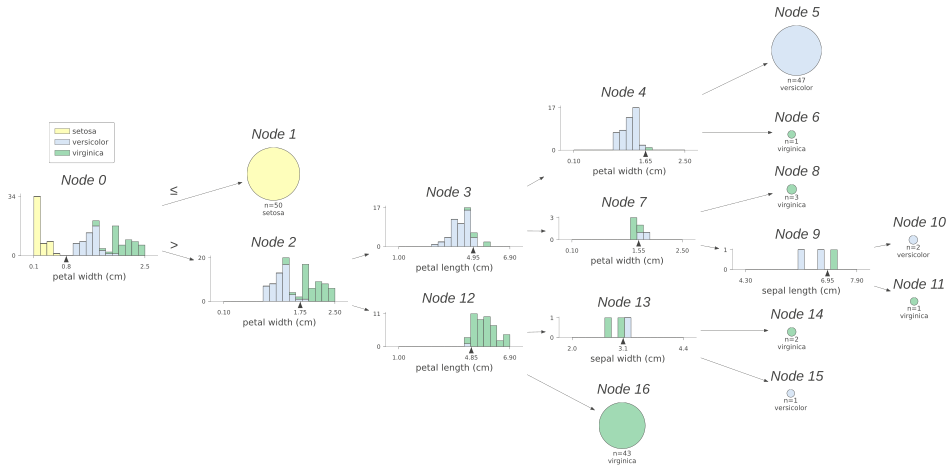

In [ ]:
m = model(
    clas,
    X_train=X_iris,
    y_train=y_iris,
    feature_names=iris.feature_names,
    class_names=['setosa', 'versicolor', 'virginica']
)

m.view(show_node_labels=True, orientation='LR')

# 6. Without Any Graphs

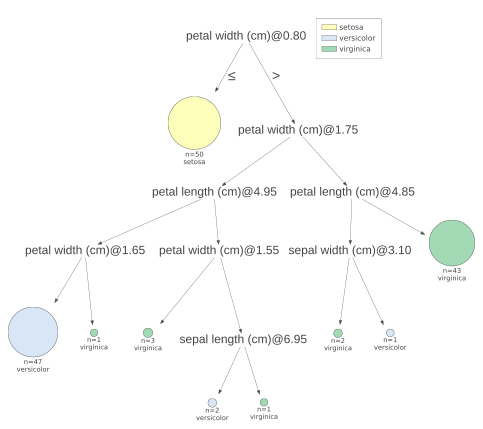

In [ ]:
m = model(
    clas,
    X_train=X_iris,
    y_train=y_iris,
    feature_names=iris.feature_names,
    class_names=['setosa', 'versicolor', 'virginica']
)

m.view(fancy=False)

# 7. Show just Prediction path, nothing else

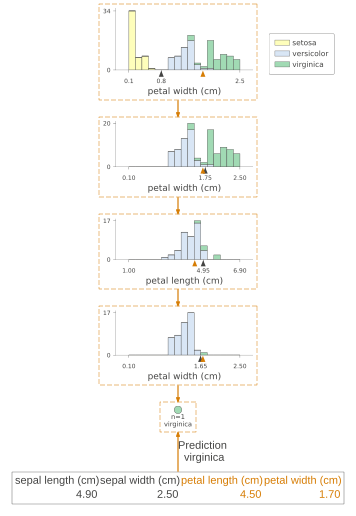

In [ ]:
m = model(
    clas,
    X_train=X_iris,
    y_train=y_iris,
    feature_names=iris.feature_names,
    class_names=['setosa', 'versicolor', 'virginica']
)

m.view(x=X, show_just_path=True)

# 8. Feature Importance

In [ ]:
# print(explain_prediction_path(clas, X, feature_names=iris.feature_names, explanation_type='sklearn_default'))

# 9. Prediction Path in Plain English

In [ ]:
# print(explain_prediction_path(clas, X, feature_names=iris.feature_names, explanation_type='plain_english'))

# 10. Regression Tree Analysis

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import pandas as pd
import dtreeviz
%config InlineBackend.figure_format = 'retina'
random_state = 1234

dataset_url = "https://raw.githubusercontent.com/parrt/dtreeviz/master/data/cars.csv"
df_cars = pd.read_csv(dataset_url)
X = df_cars.drop('MPG', axis=1)
y = df_cars['MPG']
features = list(X.columns)
x = df_cars[['CYL','ENG','WGT']].iloc[10]

dtr_cars = DecisionTreeRegressor(max_depth=3, criterion="absolute_error")
dtr_cars.fit(X.values, y.values)

DecisionTreeRegressor(criterion='absolute_error', max_depth=3)

In [ ]:
viz_rmodel = dtreeviz.model(dtr_cars, X, y, feature_names=features, target_name='MPG')

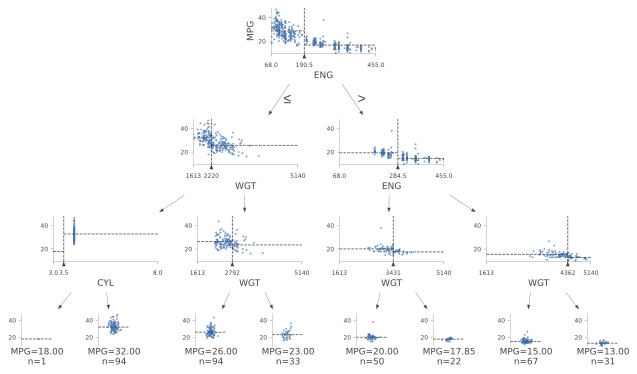

In [ ]:
# Tree structure
viz_rmodel.view()

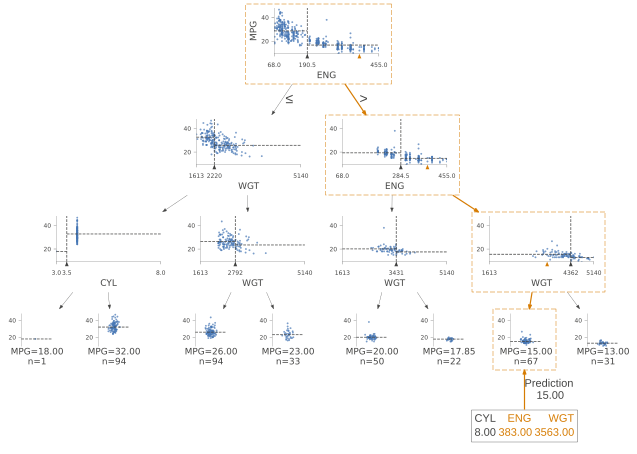

In [ ]:
# Prediction path
viz_rmodel.view(x = x)

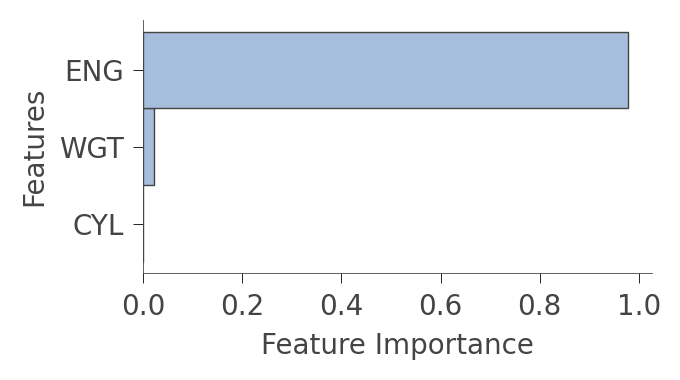

In [ ]:
viz_rmodel.instance_feature_importance(x, figsize=(3.5,2))

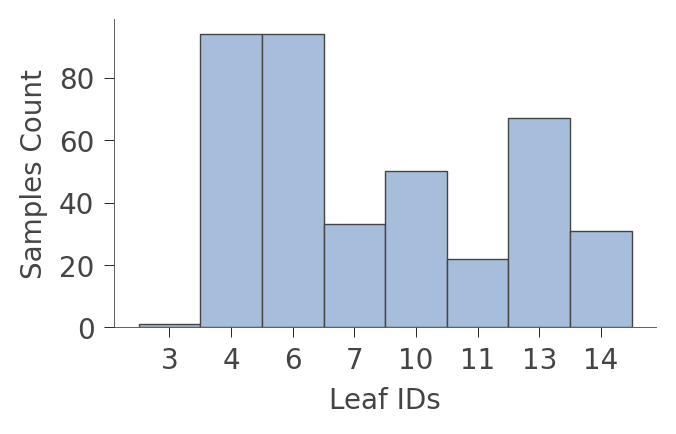

In [ ]:
viz_rmodel.leaf_sizes(figsize=(3.5,2))

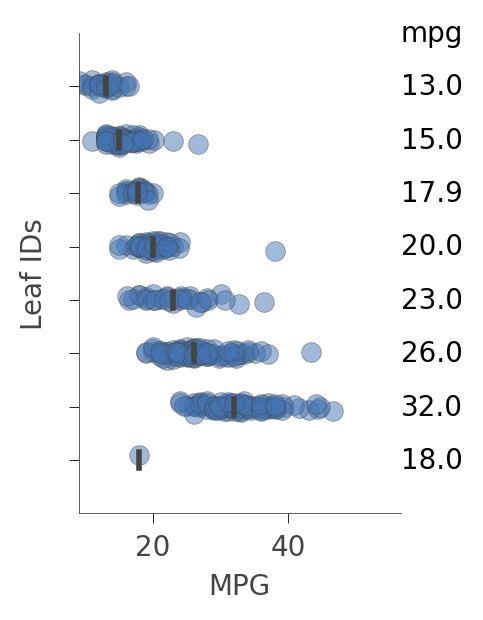

In [ ]:
viz_rmodel.rtree_leaf_distributions()

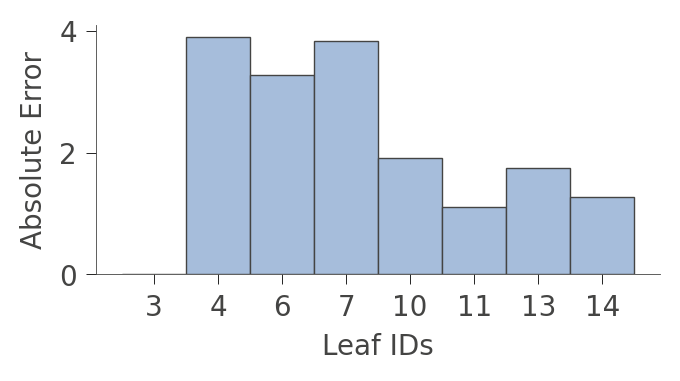

In [ ]:
viz_rmodel.leaf_purity(figsize=(3.5,2))

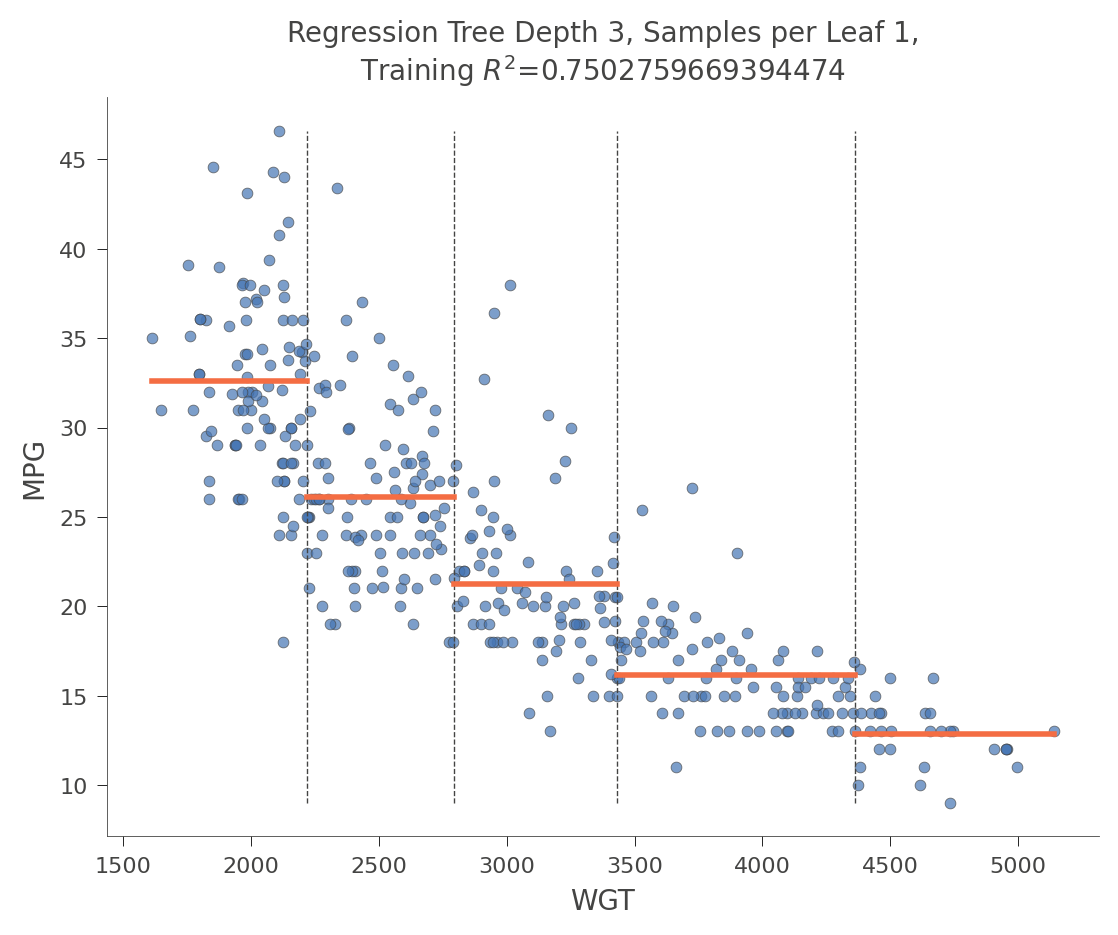

In [ ]:
viz_rmodel.rtree_feature_space(features=['WGT'])

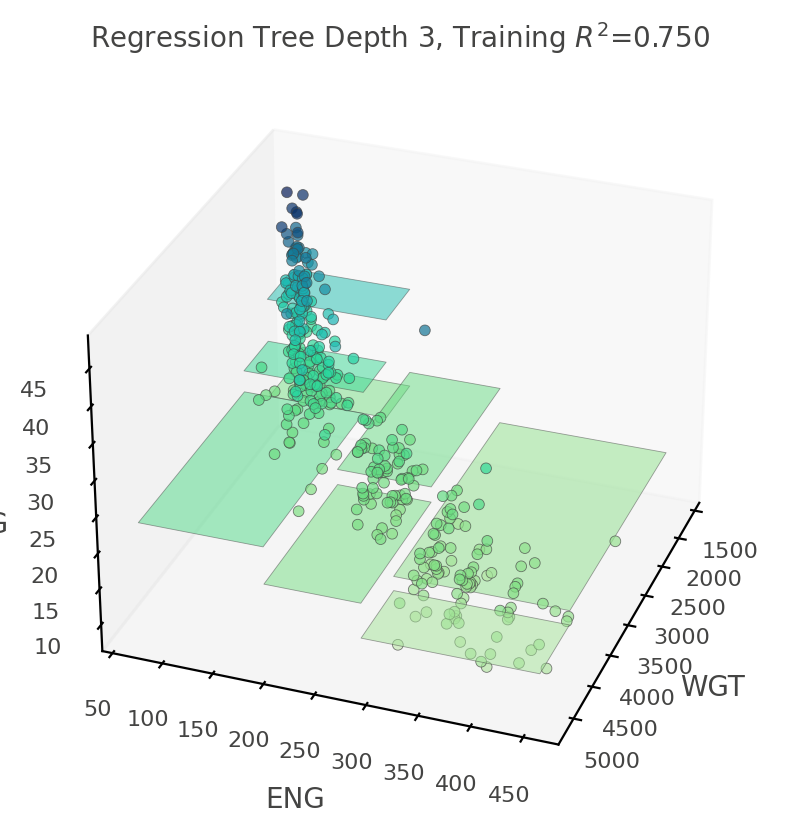

In [ ]:
viz_rmodel.rtree_feature_space3D(features=['WGT','ENG'],
                                 fontsize=10,
                                 elev=30, azim=20,
                                 show={'splits', 'title'},
                                 colors={'tessellation_alpha': .5}
                                )

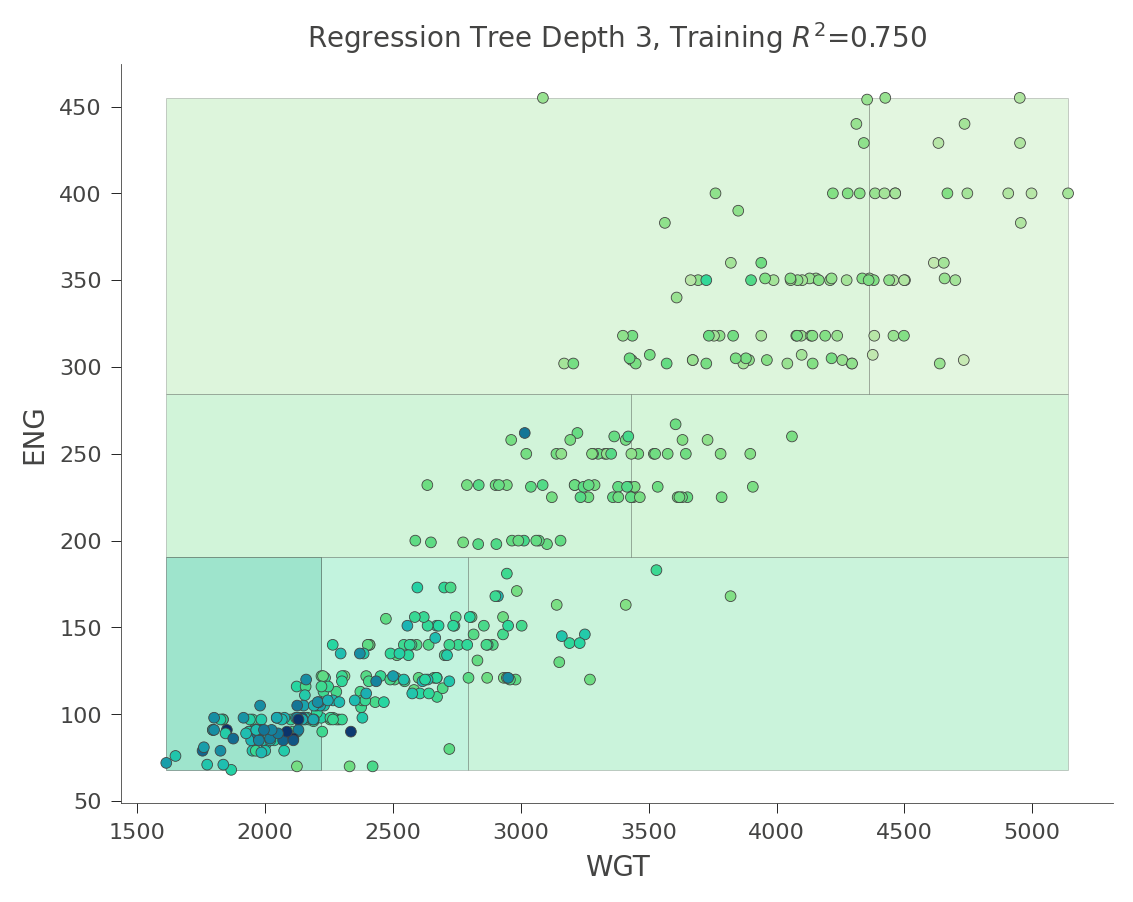

In [ ]:
viz_rmodel.rtree_feature_space(features=['WGT','ENG'])